# iTransformer + Horizon-Gated Dependency Mixture

This section implements the matched horizon-specific topology-transfer mechanism. Predictive-utility source sets are computed from training data and then imposed on the neural forecaster as specified in the paper.


In [1]:
from pathlib import Path
from types import SimpleNamespace
import gc
import importlib
import math
import random
import sys
import time
import traceback
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    free_b, total_b = torch.cuda.mem_get_info()
    print(
        f"CUDA memory: "
        f"{free_b/1024**3:.1f} / {total_b/1024**3:.1f} GiB free"
    )


Python: 3.8.10 (default, Mar 15 2022, 12:22:08) 
[GCC 9.4.0]
PyTorch: 2.4.1+cu121
Device: cuda
GPU: NVIDIA A100-SXM4-80GB
CUDA memory: 77.1 / 79.2 GiB free


## 1. Fixed protocol


In [2]:
SEED = 2026
SEQ_LEN = 96
LABEL_LEN = 48

CONDITIONS = [
    ("Electricity", 192),
    ("ETTh1", 336),
    ("ETTm1", 336),
    ("Solar", 720),
]

MIXTURE_VARIANTS = [
    "GlobalGatedMixture",
    "HorizonGatedMixture",
]

PROJECT_ROOT_CANDIDATES = [
    Path("/data/code/2026_08"),
    Path.cwd(),
]

PROJECT_ROOT = next(
    (p for p in PROJECT_ROOT_CANDIDATES if p.exists()),
    Path.cwd(),
).resolve()

BASELINE_ROOT = (
    PROJECT_ROOT
    / "results_external_baselines_phase1_direct"
)

DIAGNOSTIC_ROOT = (
    PROJECT_ROOT
    / "results_itransformer_routing_ablation_diagnostic"
)

DIAGNOSTIC_ALL4_CSV = (
    DIAGNOSTIC_ROOT
    / "routing_diagnostic_all4.csv"
)

HYBRID_ROOT = (
    PROJECT_ROOT
    / "results_itransformer_lowrank_horizon_routing_screening"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "results_itransformer_horizon_gated_dependency_mixture"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Same sparse routing convention as previous experiments.
TOP_FRAC = 0.10
MIN_TOP_K = 2
MAX_TOP_K = 20

# Same low-rank head.
LOWRANK_RANK = 16
LOWRANK_LR = 2e-3
LOWRANK_WEIGHT_DECAY = 1e-4
A_INIT_STD = 1e-3

# Gate
GATE_LR = 2e-2
GATE_WEIGHT_DECAY = 0.0
GATE_TEMPERATURE = 1.0

# Keep equal-mixture initialization.
# Residual correction itself is almost identity because A is tiny.
GATE_INIT = 0.0

MAX_EPOCHS = 12
PATIENCE = 4
GRAD_CLIP = 1.0

HORIZON_CHUNK = 4
NUM_WORKERS = 2

TEACHER_TEMPERATURE = 1.0

RESUME = True

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Conditions:", CONDITIONS)
print("Mixture variants:", MIXTURE_VARIANTS)


PROJECT_ROOT: /data/code/2026_08
OUTPUT_DIR: /data/code/2026_08/results_itransformer_horizon_gated_dependency_mixture
Conditions: [('Electricity', 192), ('ETTh1', 336), ('ETTm1', 336), ('Solar', 720)]
Mixture variants: ['GlobalGatedMixture', 'HorizonGatedMixture']


In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True


def sparse_k_and_m(C):
    possible = max(1, C - 1)

    K = int(
        math.ceil(
            TOP_FRAC * possible
        )
    )

    K = max(
        MIN_TOP_K,
        K,
    )

    K = min(
        MAX_TOP_K,
        K,
        possible,
    )

    M = max(
        2 * K,
        K + 4,
    )

    M = min(
        40,
        M,
        possible,
    )

    return K, M


def choose_batch_size(dataset_name, H):
    batch = 32

    if dataset_name == "Electricity":
        batch = min(batch, 16)

        if H >= 336:
            batch = min(batch, 8)

    if dataset_name == "Solar":
        batch = min(batch, 16)

    return batch


## 2. Time-Series-Library iTransformer


In [4]:
TSLIB_CANDIDATES = [
    Path("/data/Time-Series-Library"),
    Path("/data/Time-Series-Library_v2"),
    Path("/data/Time-Series-Library"),
    PROJECT_ROOT / "Time-Series-Library",
    PROJECT_ROOT / "Time-Series-Library_v2",
]


def is_tslib_root(p):
    p = Path(p)

    return (
        p.is_dir()
        and (p / "models" / "iTransformer.py").exists()
        and (p / "layers").is_dir()
    )


TSL_ROOT = next(
    (
        p.resolve()
        for p in TSLIB_CANDIDATES
        if is_tslib_root(p)
    ),
    None,
)

if TSL_ROOT is None:
    raise FileNotFoundError(
        "Time-Series-Library source not found."
    )

if str(TSL_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(TSL_ROOT),
    )

iTransformer_module = importlib.import_module(
    "models.iTransformer"
)

print("TSLib:", TSL_ROOT)


TSLib: /data/Time-Series-Library


## 3. Same dataset protocol as Phase-1


In [5]:
DATASET_FILES = {
    "Electricity": Path(
        "/data/dataset/electricity/electricity.csv"
    ),
    "Solar": Path(
        "/data/dataset/solar/solar_AL.txt"
    ),
    "ETTh1": Path(
        "/data/dataset/ETT-small/ETTh1.csv"
    ),
    "ETTm1": Path(
        "/data/dataset/ETT-small/ETTm1.csv"
    ),
}

DATASET_SPECS = {
    "Electricity": {
        "channels": 321,
        "freq": "h",
    },
    "Solar": {
        "channels": 137,
        "freq": "h",
    },
    "ETTh1": {
        "channels": 7,
        "freq": "h",
    },
    "ETTm1": {
        "channels": 7,
        "freq": "t",
    },
}


def load_numeric_series(dataset_name, path):
    path = Path(path)

    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)

        date_col = None

        for candidate in [
            "date",
            "datetime",
            "timestamp",
            "time",
        ]:
            if candidate in df.columns:
                date_col = candidate
                break

        if date_col is None:
            first_col = df.columns[0]

            if not pd.api.types.is_numeric_dtype(
                df[first_col]
            ):
                date_col = first_col

        if date_col is not None:
            df = df.drop(
                columns=[date_col]
            )

        df = df.select_dtypes(
            include=[np.number]
        )

        x = df.to_numpy(
            dtype=np.float32
        )

    else:
        try:
            x = np.loadtxt(
                path,
                delimiter=",",
                dtype=np.float32,
            )
        except Exception:
            x = np.loadtxt(
                path,
                dtype=np.float32,
            )

        if x.ndim == 1:
            x = x[:, None]

    if x.ndim != 2:
        raise ValueError(
            f"{dataset_name}: unexpected shape {x.shape}"
        )

    if not np.isfinite(x).all():
        raise ValueError(
            f"{dataset_name}: non-finite values"
        )

    return x


def split_boundaries(dataset_name, T):
    if dataset_name == "ETTh1":
        train_end = 12 * 30 * 24
        val_end = train_end + 4 * 30 * 24
        test_end = val_end + 4 * 30 * 24

        return (
            min(train_end, T),
            min(val_end, T),
            min(test_end, T),
        )

    if dataset_name == "ETTm1":
        unit = 30 * 24 * 4

        train_end = 12 * unit
        val_end = train_end + 4 * unit
        test_end = val_end + 4 * unit

        return (
            min(train_end, T),
            min(val_end, T),
            min(test_end, T),
        )

    return (
        int(0.70 * T),
        int(0.80 * T),
        T,
    )


def load_and_normalize(dataset_name):
    raw = load_numeric_series(
        dataset_name,
        DATASET_FILES[dataset_name],
    )

    T, C = raw.shape

    train_end, val_end, test_end = split_boundaries(
        dataset_name,
        T,
    )

    mean = raw[
        :train_end
    ].mean(
        axis=0,
        keepdims=True,
    )

    std = raw[
        :train_end
    ].std(
        axis=0,
        keepdims=True,
    )

    std = np.maximum(
        std,
        1e-6,
    )

    x = (
        raw - mean
    ) / std

    return (
        x.astype(np.float32),
        {
            "T": T,
            "C": C,
            "train_end": train_end,
            "val_end": val_end,
            "test_end": test_end,
        },
    )


class ForecastDataset(Dataset):
    def __init__(
        self,
        data,
        seq_len,
        label_len,
        pred_len,
        target_start_min,
        target_end_exclusive,
    ):
        self.data = torch.from_numpy(
            data
        ).float()

        self.seq_len = int(seq_len)
        self.label_len = int(label_len)
        self.pred_len = int(pred_len)

        first_t = max(
            self.seq_len,
            self.label_len,
            int(target_start_min),
        )

        last_t = (
            int(target_end_exclusive)
            -
            self.pred_len
        )

        self.origins = np.arange(
            first_t,
            last_t + 1,
            dtype=np.int64,
        )

        if len(self.origins) == 0:
            raise RuntimeError(
                "No valid forecasting windows."
            )

    def __len__(self):
        return len(
            self.origins
        )

    def __getitem__(self, idx):
        t = int(
            self.origins[idx]
        )

        x = self.data[
            t-self.seq_len:
            t
        ]

        y = self.data[
            t-self.label_len:
            t+self.pred_len
        ]

        return x, y


def prepare_datasets(dataset_name, H):
    x, meta = load_and_normalize(
        dataset_name
    )

    expected_C = DATASET_SPECS[
        dataset_name
    ][
        "channels"
    ]

    if meta["C"] != expected_C:
        raise RuntimeError(
            f"{dataset_name}: detected C={meta['C']}, expected {expected_C}"
        )

    train_ds = ForecastDataset(
        x,
        SEQ_LEN,
        LABEL_LEN,
        H,
        target_start_min=SEQ_LEN,
        target_end_exclusive=meta["train_end"],
    )

    val_ds = ForecastDataset(
        x,
        SEQ_LEN,
        LABEL_LEN,
        H,
        target_start_min=meta["train_end"],
        target_end_exclusive=meta["val_end"],
    )

    test_ds = ForecastDataset(
        x,
        SEQ_LEN,
        LABEL_LEN,
        H,
        target_start_min=meta["val_end"],
        target_end_exclusive=meta["test_end"],
    )

    return (
        x,
        train_ds,
        val_ds,
        test_ds,
        meta,
    )


def make_loaders(
    train_ds,
    val_ds,
    test_ds,
    batch_size,
    seed,
):
    g = torch.Generator()

    g.manual_seed(
        seed + 100000
    )

    common = dict(
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        **common,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        **common,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        **common,
    )

    return (
        train_loader,
        val_loader,
        test_loader,
    )


## 4. Load exact Phase-1 iTransformer


In [6]:
def build_itransformer_args(dataset_name, H):
    spec = DATASET_SPECS[
        dataset_name
    ]

    return SimpleNamespace(
        task_name="long_term_forecast",
        model="iTransformer",

        seq_len=SEQ_LEN,
        label_len=LABEL_LEN,
        pred_len=H,

        enc_in=spec["channels"],
        dec_in=spec["channels"],
        c_out=spec["channels"],

        e_layers=3,
        d_layers=1,
        n_heads=8,
        d_model=512,
        d_ff=512,
        factor=3,
        dropout=0.1,

        embed="timeF",
        freq=spec["freq"],
        activation="gelu",
        output_attention=False,

        class_strategy="projection",
        use_norm=1,

        moving_avg=25,
        distil=True,
        top_k=5,
        num_kernels=6,
        seasonal_patterns="Monthly",
        inverse=False,
    )


def itransformer_condition_dir(dataset_name, H):
    return (
        BASELINE_ROOT
        / "iTransformer"
        / dataset_name
        / f"H{H}"
    )


def build_and_load_itransformer(dataset_name, H):
    args = build_itransformer_args(
        dataset_name,
        H,
    )

    model = (
        iTransformer_module
        .Model(args)
        .float()
        .to(DEVICE)
    )

    ckpt = (
        itransformer_condition_dir(
            dataset_name,
            H,
        )
        / "best_model.pt"
    )

    if not ckpt.exists():
        raise FileNotFoundError(
            ckpt
        )

    state = torch.load(
        ckpt,
        map_location="cpu",
    )

    model.load_state_dict(
        state,
        strict=True,
    )

    model.eval()

    for p in model.parameters():
        p.requires_grad = False

    return model


## 5. Reuse exact Predictive-Utility Teacher caches


In [7]:
def teacher_filename(dataset_name, H):
    return (
        f"{dataset_name}_H{H}_predictive_topk.npz"
    )


def find_teacher_cache(dataset_name, H):
    filename = teacher_filename(
        dataset_name,
        H,
    )

    search_dirs = [
        HYBRID_ROOT
        / "predictive_teacher_cache",

        PROJECT_ROOT
        / "results_itransformer_horizon_routing_screening"
        / "predictive_teacher_cache",

        PROJECT_ROOT
        / "results_final_protocol_hybrid0_H96_H720"
        / "predictive_teacher_cache",

        PROJECT_ROOT
        / "results_intermediate_horizon_hybrid_router"
        / "predictive_teacher_cache",
    ]

    for root in search_dirs:
        p = root / filename

        if p.exists():
            return p

    matches = list(
        PROJECT_ROOT.glob(
            f"results*/**/{filename}"
        )
    )

    if matches:
        return matches[0]

    raise FileNotFoundError(
        f"Teacher cache not found: {dataset_name} H={H}"
    )


def load_teacher(dataset_name, H, C):
    path = find_teacher_cache(
        dataset_name,
        H,
    )

    cache = np.load(path)

    idx = cache[
        "oracle_idx"
    ].astype(
        np.int64
    )

    gain = cache[
        "oracle_gain"
    ].astype(
        np.float32
    )

    K, _ = sparse_k_and_m(C)

    expected = (
        H,
        C,
        K,
    )

    if (
        idx.shape != expected
        or
        gain.shape != expected
    ):
        raise RuntimeError(
            f"Teacher shape mismatch: found {idx.shape}, expected {expected}"
        )

    g = torch.as_tensor(
        gain,
        dtype=torch.float32,
    )

    g_mean = g.mean(
        dim=-1,
        keepdim=True,
    )

    g_std = g.std(
        dim=-1,
        keepdim=True,
    ).clamp_min(
        1e-6
    )

    prob = torch.softmax(
        (
            g - g_mean
        )
        /
        g_std
        /
        TEACHER_TEMPERATURE,
        dim=-1,
    )

    return (
        idx,
        prob.numpy().astype(
            np.float32
        ),
        path,
    )


for d, H in CONDITIONS:
    p = find_teacher_cache(
        d,
        H,
    )
    print(
        d,
        H,
        "->",
        p,
    )


Electricity 192 -> /data/code/2026_08/results_intermediate_horizon_hybrid_router/predictive_teacher_cache/Electricity_H192_predictive_topk.npz
ETTh1 336 -> /data/code/2026_08/results_intermediate_horizon_hybrid_router/predictive_teacher_cache/ETTh1_H336_predictive_topk.npz
ETTm1 336 -> /data/code/2026_08/results_intermediate_horizon_hybrid_router/predictive_teacher_cache/ETTm1_H336_predictive_topk.npz
Solar 720 -> /data/code/2026_08/results_oracle_predictive_routing/oracle_cache/Solar_H720_predictive_topk.npz


## 6. Gated dependency-mixture model


In [8]:
class GatedDependencyMixture(nn.Module):
    """
    Frozen iTransformer +
      Global context
      Dynamic Top-K context
      Predictive horizon-specific context
    +
      Global or horizon-specific 3-way mechanism gate
    +
      rank-16 low-rank residual forecast head.
    """

    def __init__(
        self,
        base_model,
        variant,
        teacher_idx,
        teacher_prob,
        rank=16,
    ):
        super().__init__()

        if variant not in {
            "GlobalGatedMixture",
            "HorizonGatedMixture",
        }:
            raise ValueError(
                variant
            )

        self.base = base_model
        self.variant = variant

        self.H = int(
            base_model.pred_len
        )

        self.C = int(
            teacher_idx.shape[1]
        )

        self.K = int(
            teacher_idx.shape[2]
        )

        self.rank = int(rank)

        self.d_model = int(
            base_model.projection.in_features
        )

        for p in self.base.parameters():
            p.requires_grad = False

        self.base.eval()

        self.register_buffer(
            "teacher_idx",
            torch.as_tensor(
                teacher_idx,
                dtype=torch.long,
                device=DEVICE,
            ),
        )

        self.register_buffer(
            "teacher_prob",
            torch.as_tensor(
                teacher_prob,
                dtype=torch.float32,
                device=DEVICE,
            ),
        )

        if self.variant == "GlobalGatedMixture":
            self.gate_logits = nn.Parameter(
                torch.full(
                    (3,),
                    float(GATE_INIT),
                    device=DEVICE,
                )
            )

        else:
            self.gate_logits = nn.Parameter(
                torch.full(
                    (self.H, 3),
                    float(GATE_INIT),
                    device=DEVICE,
                )
            )

        self.source_proj = nn.Parameter(
            torch.empty(
                self.rank,
                self.d_model,
                device=DEVICE,
            )
        )

        nn.init.normal_(
            self.source_proj,
            mean=0.0,
            std=1.0 / math.sqrt(
                self.d_model
            ),
        )

        self.horizon_coeff = nn.Parameter(
            torch.empty(
                self.H,
                self.rank,
                device=DEVICE,
            )
        )

        nn.init.normal_(
            self.horizon_coeff,
            mean=0.0,
            std=A_INIT_STD,
        )

        self.force_identity = False

    def train(
        self,
        mode=True,
    ):
        super().train(mode)
        self.base.eval()
        return self

    def gate_weights(self):
        if self.variant == "GlobalGatedMixture":
            w = torch.softmax(
                self.gate_logits
                /
                GATE_TEMPERATURE,
                dim=-1,
            )

            return w[
                None,
                :
            ].expand(
                self.H,
                -1,
            )

        return torch.softmax(
            self.gate_logits
            /
            GATE_TEMPERATURE,
            dim=-1,
        )

    @torch.no_grad()
    def _encode(
        self,
        x,
    ):
        means = (
            x
            .mean(
                1,
                keepdim=True,
            )
            .detach()
        )

        x_norm = (
            x - means
        )

        stdev = torch.sqrt(
            torch.var(
                x_norm,
                dim=1,
                keepdim=True,
                unbiased=False,
            )
            +
            1e-5
        )

        x_norm = (
            x_norm
            /
            stdev
        )

        B, L, N = x_norm.shape

        z = self.base.enc_embedding(
            x_norm,
            None,
        )

        z, _ = self.base.encoder(
            z,
            attn_mask=None,
        )

        z = z[
            :,
            :N,
            :
        ]

        base_norm = (
            self.base
            .projection(z)
            .permute(
                0,
                2,
                1,
            )
        )

        return (
            z,
            base_norm,
            means,
            stdev,
        )

    def _global_context(
        self,
        z,
    ):
        C = z.shape[1]

        if C <= 1:
            return z

        total = z.sum(
            dim=1,
            keepdim=True,
        )

        return (
            total - z
        ) / float(
            C - 1
        )

    def _dynamic_context(
        self,
        z,
    ):
        B, C, D = z.shape

        z_unit = F.normalize(
            z.float(),
            dim=-1,
            eps=1e-6,
        )

        score = torch.einsum(
            "bid,bjd->bij",
            z_unit,
            z_unit,
        )

        eye = torch.eye(
            C,
            device=z.device,
            dtype=torch.bool,
        )[
            None,
            :,
            :
        ]

        score = score.masked_fill(
            eye,
            float("-inf"),
        )

        values, idx = torch.topk(
            score,
            k=self.K,
            dim=-1,
        )

        weights = torch.softmax(
            values,
            dim=-1,
        )

        batch_idx = torch.arange(
            B,
            device=z.device,
        )[
            :,
            None,
            None,
        ]

        selected_z = z[
            batch_idx,
            idx,
        ]

        context = (
            weights
            .unsqueeze(-1)
            *
            selected_z
        ).sum(
            dim=2
        )

        return context

    def forward(
        self,
        x,
    ):
        (
            z,
            base_norm,
            means,
            stdev,
        ) = self._encode(
            x
        )

        if self.force_identity:
            pred_norm = base_norm

        else:
            B, C, D = z.shape

            global_context = self._global_context(
                z
            )

            dynamic_context = self._dynamic_context(
                z
            )

            gate_all = self.gate_weights()

            pred_parts = []

            for h_start in range(
                0,
                self.H,
                HORIZON_CHUNK,
            ):
                h_end = min(
                    self.H,
                    h_start + HORIZON_CHUNK,
                )

                Hc = (
                    h_end - h_start
                )

                teacher_idx = self.teacher_idx[
                    h_start:
                    h_end
                ]

                teacher_prob = self.teacher_prob[
                    h_start:
                    h_end
                ]

                idx_b = (
                    teacher_idx
                    .unsqueeze(0)
                    .expand(
                        B,
                        -1,
                        -1,
                        -1,
                    )
                )

                batch_idx = torch.arange(
                    B,
                    device=z.device,
                )[
                    :,
                    None,
                    None,
                    None,
                ]

                selected_z = z[
                    batch_idx,
                    idx_b,
                ]

                predictive_context = (
                    teacher_prob[
                        None,
                        :,
                        :,
                        :
                    ]
                    .unsqueeze(-1)
                    *
                    selected_z
                ).sum(
                    dim=3
                )

                global_h = (
                    global_context
                    .unsqueeze(1)
                    .expand(
                        -1,
                        Hc,
                        -1,
                        -1,
                    )
                )

                dynamic_h = (
                    dynamic_context
                    .unsqueeze(1)
                    .expand(
                        -1,
                        Hc,
                        -1,
                        -1,
                    )
                )

                gates = gate_all[
                    h_start:
                    h_end
                ]

                w_g = gates[
                    :,
                    0
                ][
                    None,
                    :,
                    None,
                    None,
                ]

                w_d = gates[
                    :,
                    1
                ][
                    None,
                    :,
                    None,
                    None,
                ]

                w_p = gates[
                    :,
                    2
                ][
                    None,
                    :,
                    None,
                    None,
                ]

                context = (
                    w_g
                    *
                    global_h
                    +
                    w_d
                    *
                    dynamic_h
                    +
                    w_p
                    *
                    predictive_context
                )

                target_z = (
                    z[
                        :,
                        None,
                        :,
                        :
                    ]
                    .expand(
                        -1,
                        Hc,
                        -1,
                        -1,
                    )
                )

                delta_token = (
                    context
                    -
                    target_z
                )

                low = torch.einsum(
                    "bhcd,rd->bhcr",
                    delta_token,
                    self.source_proj,
                )

                A_h = self.horizon_coeff[
                    h_start:
                    h_end
                ]

                delta_norm = torch.einsum(
                    "bhcr,hr->bhc",
                    low,
                    A_h,
                )

                pred_chunk = (
                    base_norm[
                        :,
                        h_start:
                        h_end,
                        :
                    ]
                    +
                    delta_norm
                )

                pred_parts.append(
                    pred_chunk
                )

            pred_norm = torch.cat(
                pred_parts,
                dim=1,
            )

        pred = (
            pred_norm
            *
            stdev[
                :,
                0,
                :
            ]
            .unsqueeze(1)
            +
            means[
                :,
                0,
                :
            ]
            .unsqueeze(1)
        )

        return pred


## 7. Evaluation


In [9]:
@torch.no_grad()
def evaluate_base(
    base,
    loader,
    H,
):
    base.eval()

    sse = 0.0
    sae = 0.0
    n = 0

    for x, y in loader:
        x = x.float().to(
            DEVICE,
            non_blocking=True,
        )

        y = y.float().to(
            DEVICE,
            non_blocking=True,
        )

        pred = base(
            x,
            None,
            None,
            None,
        )[
            :,
            -H:,
            :
        ]

        target = y[
            :,
            -H:,
            :
        ]

        err = pred - target

        sse += (
            err.square()
            .sum()
            .item()
        )

        sae += (
            err.abs()
            .sum()
            .item()
        )

        n += err.numel()

    return (
        sse / n,
        sae / n,
    )


@torch.no_grad()
def evaluate_model(
    model,
    loader,
    H,
):
    model.eval()

    sse = 0.0
    sae = 0.0
    n = 0

    step_sse = None
    step_sae = None
    step_n = 0

    for x, y in loader:
        x = x.float().to(
            DEVICE,
            non_blocking=True,
        )

        y = y.float().to(
            DEVICE,
            non_blocking=True,
        )

        pred = model(x)

        target = y[
            :,
            -H:,
            :
        ]

        err = pred - target

        sse += (
            err.square()
            .sum()
            .item()
        )

        sae += (
            err.abs()
            .sum()
            .item()
        )

        n += err.numel()

        this_sse = (
            err.square()
            .sum(
                dim=(0, 2)
            )
            .detach()
            .cpu()
        )

        this_sae = (
            err.abs()
            .sum(
                dim=(0, 2)
            )
            .detach()
            .cpu()
        )

        if step_sse is None:
            step_sse = this_sse
            step_sae = this_sae

        else:
            step_sse += this_sse
            step_sae += this_sae

        step_n += (
            target.shape[0]
            *
            target.shape[2]
        )

    return (
        sse / n,
        sae / n,
        (
            step_sse
            /
            step_n
        ).numpy(),
        (
            step_sae
            /
            step_n
        ).numpy(),
    )


## 8. Validation-gated training


In [10]:
def train_mixture(
    model,
    train_loader,
    val_loader,
    H,
    baseline_val_mse,
):
    optimizer = torch.optim.AdamW(
        [
            {
                "params": [
                    model.gate_logits
                ],
                "lr": GATE_LR,
                "weight_decay": GATE_WEIGHT_DECAY,
            },
            {
                "params": [
                    model.source_proj,
                    model.horizon_coeff,
                ],
                "lr": LOWRANK_LR,
                "weight_decay": LOWRANK_WEIGHT_DECAY,
            },
        ]
    )

    best_val = float(
        baseline_val_mse
    )

    best_epoch = 0
    best_state = None
    bad = 0
    history = []

    for epoch in range(
        1,
        MAX_EPOCHS + 1,
    ):
        model.train()
        model.force_identity = False

        train_sse = 0.0
        train_n = 0

        for x, y in train_loader:
            x = x.float().to(
                DEVICE,
                non_blocking=True,
            )

            y = y.float().to(
                DEVICE,
                non_blocking=True,
            )

            target = y[
                :,
                -H:,
                :
            ]

            optimizer.zero_grad(
                set_to_none=True
            )

            pred = model(x)

            loss = F.mse_loss(
                pred,
                target,
            )

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    "Non-finite loss."
                )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                [
                    model.gate_logits,
                    model.source_proj,
                    model.horizon_coeff,
                ],
                GRAD_CLIP,
            )

            optimizer.step()

            train_sse += (
                (
                    pred.detach()
                    -
                    target
                )
                .square()
                .sum()
                .item()
            )

            train_n += target.numel()

        (
            val_mse,
            val_mae,
            _,
            _,
        ) = evaluate_model(
            model,
            val_loader,
            H,
        )

        gates = (
            model.gate_weights()
            .detach()
            .cpu()
            .numpy()
        )

        gate_entropy = (
            -gates
            *
            np.log(
                np.clip(
                    gates,
                    1e-12,
                    1.0,
                )
            )
        ).sum(
            axis=1
        ).mean()

        row = {
            "epoch": epoch,
            "train_mse": (
                train_sse
                /
                train_n
            ),
            "val_mse": val_mse,
            "val_mae": val_mae,
            "gate_global_mean": float(
                gates[
                    :,
                    0
                ].mean()
            ),
            "gate_dynamic_mean": float(
                gates[
                    :,
                    1
                ].mean()
            ),
            "gate_predictive_mean": float(
                gates[
                    :,
                    2
                ].mean()
            ),
            "gate_entropy_mean": float(
                gate_entropy
            ),
        }

        history.append(row)

        print(
            f"epoch={epoch:02d} | "
            f"train={row['train_mse']:.6f} | "
            f"val={val_mse:.6f} | "
            f"G/D/P="
            f"{row['gate_global_mean']:.3f}/"
            f"{row['gate_dynamic_mean']:.3f}/"
            f"{row['gate_predictive_mean']:.3f}"
        )

        if val_mse < best_val:
            best_val = val_mse
            best_epoch = epoch

            best_state = {
                "gate_logits": (
                    model.gate_logits
                    .detach()
                    .cpu()
                    .clone()
                ),
                "source_proj": (
                    model.source_proj
                    .detach()
                    .cpu()
                    .clone()
                ),
                "horizon_coeff": (
                    model.horizon_coeff
                    .detach()
                    .cpu()
                    .clone()
                ),
            }

            bad = 0

        else:
            bad += 1

            if bad >= PATIENCE:
                print(
                    "Early stopping."
                )
                break

    if best_state is None:
        model.force_identity = True
        selected = "Identity"

    else:
        with torch.no_grad():
            model.gate_logits.copy_(
                best_state[
                    "gate_logits"
                ].to(DEVICE)
            )

            model.source_proj.copy_(
                best_state[
                    "source_proj"
                ].to(DEVICE)
            )

            model.horizon_coeff.copy_(
                best_state[
                    "horizon_coeff"
                ].to(DEVICE)
            )

        model.force_identity = False
        selected = model.variant

    return (
        model,
        best_val,
        best_epoch,
        selected,
        pd.DataFrame(history),
    )


## 9. Pre-flight: identity and parameter count


In [11]:
pf_dataset = "ETTh1"
pf_H = 336

(
    x_pf,
    train_pf,
    val_pf,
    test_pf,
    meta_pf,
) = prepare_datasets(
    pf_dataset,
    pf_H,
)

(
    train_loader_pf,
    val_loader_pf,
    test_loader_pf,
) = make_loaders(
    train_pf,
    val_pf,
    test_pf,
    choose_batch_size(
        pf_dataset,
        pf_H,
    ),
    SEED,
)

base_pf = build_and_load_itransformer(
    pf_dataset,
    pf_H,
)

teacher_idx_pf, teacher_prob_pf, _ = load_teacher(
    pf_dataset,
    pf_H,
    meta_pf["C"],
)

for variant_pf in MIXTURE_VARIANTS:
    model_pf = GatedDependencyMixture(
        base_pf,
        variant_pf,
        teacher_idx_pf,
        teacher_prob_pf,
        rank=LOWRANK_RANK,
    ).to(DEVICE)

    model_pf.force_identity = True

    x_batch_pf, _ = next(
        iter(
            test_loader_pf
        )
    )

    x_batch_pf = (
        x_batch_pf
        .float()
        .to(DEVICE)
    )

    with torch.no_grad():
        p_base_pf = base_pf(
            x_batch_pf,
            None,
            None,
            None,
        )[
            :,
            -pf_H:,
            :
        ]

        p_id_pf = model_pf(
            x_batch_pf
        )

    identity_error_pf = (
        p_base_pf
        -
        p_id_pf
    ).abs().max().item()

    new_params_pf = sum(
        p.numel()
        for p in model_pf.parameters()
        if p.requires_grad
    )

    gate_params_pf = (
        3
        if variant_pf == "GlobalGatedMixture"
        else
        3 * pf_H
    )

    expected_params_pf = (
        LOWRANK_RANK
        *
        model_pf.d_model
        +
        pf_H
        *
        LOWRANK_RANK
        +
        gate_params_pf
    )

    print(
        variant_pf,
        "| identity error:",
        identity_error_pf,
        "| trainable:",
        new_params_pf,
        "| expected:",
        expected_params_pf,
    )

    assert identity_error_pf < 2e-5
    assert new_params_pf == expected_params_pf

    del (
        model_pf,
        x_batch_pf,
        p_base_pf,
        p_id_pf,
    )

del (
    x_pf,
    train_pf,
    val_pf,
    test_pf,
    train_loader_pf,
    val_loader_pf,
    test_loader_pf,
    base_pf,
)

gc.collect()

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print("Pre-flight: PASSED")


GlobalGatedMixture | identity error: 0.0 | trainable: 13571 | expected: 13571
HorizonGatedMixture | identity error: 0.0 | trainable: 14576 | expected: 14576
Pre-flight: PASSED


## 10. Run 8 mixture experiments


In [12]:
def variant_dir(
    dataset_name,
    H,
    variant,
):
    p = (
        OUTPUT_DIR
        / dataset_name
        / f"H{H}"
        / variant
    )

    p.mkdir(
        parents=True,
        exist_ok=True,
    )

    return p


def load_completed(
    dataset_name,
    H,
    variant,
):
    p = (
        variant_dir(
            dataset_name,
            H,
            variant,
        )
        / "result.csv"
    )

    if not p.exists():
        return None

    try:
        df = pd.read_csv(p)

        if len(df) != 1:
            return None

        return df.iloc[0].to_dict()

    except Exception:
        return None


all_results = []
failures = []

total_runs = (
    len(CONDITIONS)
    *
    len(MIXTURE_VARIANTS)
)

run_idx = 0

for dataset_name, H in CONDITIONS:
    (
        x_norm,
        train_ds,
        val_ds,
        test_ds,
        meta,
    ) = prepare_datasets(
        dataset_name,
        H,
    )

    batch_size = choose_batch_size(
        dataset_name,
        H,
    )

    teacher_idx, teacher_prob, teacher_path = load_teacher(
        dataset_name,
        H,
        meta["C"],
    )

    for variant in MIXTURE_VARIANTS:
        run_idx += 1

        print(
            "\n"
            +
            "=" * 118
        )

        print(
            f"[{run_idx}/{total_runs}] "
            f"{dataset_name} H={H} | {variant}"
        )

        print(
            "=" * 118
        )

        if RESUME:
            old = load_completed(
                dataset_name,
                H,
                variant,
            )

            if old is not None:
                print(
                    "Reusing completed result."
                )

                all_results.append(
                    old
                )

                continue

        try:
            set_seed(SEED)

            (
                train_loader,
                val_loader,
                test_loader,
            ) = make_loaders(
                train_ds,
                val_ds,
                test_ds,
                batch_size,
                SEED,
            )

            base = build_and_load_itransformer(
                dataset_name,
                H,
            )

            base_val_mse, base_val_mae = evaluate_base(
                base,
                val_loader,
                H,
            )

            base_test_mse, base_test_mae = evaluate_base(
                base,
                test_loader,
                H,
            )

            model = GatedDependencyMixture(
                base,
                variant,
                teacher_idx,
                teacher_prob,
                rank=LOWRANK_RANK,
            ).to(DEVICE)

            start = time.time()

            (
                model,
                best_val,
                best_epoch,
                selected,
                history,
            ) = train_mixture(
                model,
                train_loader,
                val_loader,
                H,
                base_val_mse,
            )

            (
                test_mse,
                test_mae,
                step_mse,
                step_mae,
            ) = evaluate_model(
                model,
                test_loader,
                H,
            )

            mse_gain = (
                100.0
                *
                (
                    base_test_mse
                    -
                    test_mse
                )
                /
                base_test_mse
            )

            mae_gain = (
                100.0
                *
                (
                    base_test_mae
                    -
                    test_mae
                )
                /
                base_test_mae
            )

            gates = (
                model.gate_weights()
                .detach()
                .cpu()
                .numpy()
            )

            dominant = gates.argmax(
                axis=1
            )

            gate_entropy = (
                -gates
                *
                np.log(
                    np.clip(
                        gates,
                        1e-12,
                        1.0,
                    )
                )
            ).sum(
                axis=1
            )

            if H > 1:
                gate_tv = np.abs(
                    np.diff(
                        gates,
                        axis=0,
                    )
                ).mean()

            else:
                gate_tv = 0.0

            new_params = sum(
                p.numel()
                for p in model.parameters()
                if p.requires_grad
            )

            result = {
                "dataset": dataset_name,
                "pred_len": H,
                "variant": variant,
                "selected": selected,
                "best_epoch": best_epoch,

                "base_val_mse": base_val_mse,
                "best_val_mse": best_val,

                "base_test_mse": base_test_mse,
                "test_mse": test_mse,

                "base_test_mae": base_test_mae,
                "test_mae": test_mae,

                "mse_gain_vs_iTransformer_%": mse_gain,
                "mae_gain_vs_iTransformer_%": mae_gain,

                "gate_global_mean": float(
                    gates[
                        :,
                        0
                    ].mean()
                ),
                "gate_dynamic_mean": float(
                    gates[
                        :,
                        1
                    ].mean()
                ),
                "gate_predictive_mean": float(
                    gates[
                        :,
                        2
                    ].mean()
                ),

                "gate_entropy_mean": float(
                    gate_entropy.mean()
                ),

                "gate_total_variation": float(
                    gate_tv
                ),

                "dominant_global_frac": float(
                    (
                        dominant
                        ==
                        0
                    ).mean()
                ),
                "dominant_dynamic_frac": float(
                    (
                        dominant
                        ==
                        1
                    ).mean()
                ),
                "dominant_predictive_frac": float(
                    (
                        dominant
                        ==
                        2
                    ).mean()
                ),

                "new_trainable_params": new_params,
                "runtime_sec": (
                    time.time()
                    -
                    start
                ),

                "teacher_cache": str(
                    teacher_path
                ),
            }

            pd.DataFrame(
                [result]
            ).to_csv(
                variant_dir(
                    dataset_name,
                    H,
                    variant,
                )
                / "result.csv",
                index=False,
            )

            history.to_csv(
                variant_dir(
                    dataset_name,
                    H,
                    variant,
                )
                / "history.csv",
                index=False,
            )

            pd.DataFrame({
                "horizon_step": np.arange(
                    1,
                    H + 1,
                ),
                "gate_global": gates[
                    :,
                    0
                ],
                "gate_dynamic": gates[
                    :,
                    1
                ],
                "gate_predictive": gates[
                    :,
                    2
                ],
                "gate_entropy": gate_entropy,
                "test_step_mse": step_mse,
                "test_step_mae": step_mae,
            }).to_csv(
                variant_dir(
                    dataset_name,
                    H,
                    variant,
                )
                / "per_horizon.csv",
                index=False,
            )

            torch.save(
                {
                    "gate_logits": (
                        model.gate_logits
                        .detach()
                        .cpu()
                    ),
                    "source_proj": (
                        model.source_proj
                        .detach()
                        .cpu()
                    ),
                    "horizon_coeff": (
                        model.horizon_coeff
                        .detach()
                        .cpu()
                    ),
                    "variant": variant,
                    "dataset": dataset_name,
                    "pred_len": H,
                    "seed": SEED,
                    "rank": LOWRANK_RANK,
                },
                variant_dir(
                    dataset_name,
                    H,
                    variant,
                )
                / "mixture_head.pt",
            )

            all_results.append(
                result
            )

            print(
                f"TEST | "
                f"base={base_test_mse:.6f} | "
                f"mixture={test_mse:.6f} | "
                f"MSE gain={mse_gain:+.3f}% | "
                f"MAE gain={mae_gain:+.3f}% | "
                f"G/D/P="
                f"{result['gate_global_mean']:.3f}/"
                f"{result['gate_dynamic_mean']:.3f}/"
                f"{result['gate_predictive_mean']:.3f} | "
                f"selected={selected}"
            )

            del (
                train_loader,
                val_loader,
                test_loader,
                base,
                model,
            )

            gc.collect()

            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

        except Exception:
            err = traceback.format_exc()

            failures.append({
                "dataset": dataset_name,
                "pred_len": H,
                "variant": variant,
                "error": err,
            })

            print(
                err[-6000:]
            )

        pd.DataFrame(
            all_results
        ).to_csv(
            OUTPUT_DIR
            / "mixture_partial.csv",
            index=False,
        )

        if failures:
            pd.DataFrame(
                failures
            ).to_csv(
                OUTPUT_DIR
                / "mixture_failures.csv",
                index=False,
            )

    del (
        x_norm,
        train_ds,
        val_ds,
        test_ds,
    )

    gc.collect()

results_df = pd.DataFrame(
    all_results
)

results_df.to_csv(
    OUTPUT_DIR
    / "horizon_gated_dependency_mixture_results.csv",
    index=False,
)

print(
    "\nCompleted:",
    len(results_df),
    "/",
    total_runs,
)

print(
    "Failures:",
    len(failures),
)



[1/8] Electricity H=192 | GlobalGatedMixture
epoch=01 | train=0.153402 | val=0.142202 | G/D/P=0.354/0.594/0.052
epoch=02 | train=0.153312 | val=0.142221 | G/D/P=0.304/0.677/0.019
epoch=03 | train=0.153262 | val=0.142136 | G/D/P=0.338/0.652/0.010
epoch=04 | train=0.153238 | val=0.142173 | G/D/P=0.237/0.759/0.004
epoch=05 | train=0.153221 | val=0.142138 | G/D/P=0.321/0.677/0.002
epoch=06 | train=0.153202 | val=0.142107 | G/D/P=0.336/0.663/0.001
epoch=07 | train=0.153196 | val=0.142152 | G/D/P=0.242/0.758/0.001
epoch=08 | train=0.153186 | val=0.142068 | G/D/P=0.312/0.687/0.000
epoch=09 | train=0.153179 | val=0.142093 | G/D/P=0.279/0.721/0.000
epoch=10 | train=0.153176 | val=0.142107 | G/D/P=0.304/0.696/0.000
epoch=11 | train=0.153171 | val=0.142122 | G/D/P=0.253/0.747/0.000
epoch=12 | train=0.153170 | val=0.142091 | G/D/P=0.267/0.733/0.000
Early stopping.
TEST | base=0.164334 | mixture=0.163882 | MSE gain=+0.275% | MAE gain=+0.100% | G/D/P=0.312/0.687/0.000 | selected=GlobalGatedMixture


## 11. Main paired result


In [13]:
if len(results_df) == 0:
    raise RuntimeError(
        "No completed mixture results."
    )

display(
    results_df[
        [
            "dataset",
            "pred_len",
            "variant",
            "selected",
            "base_test_mse",
            "test_mse",
            "mse_gain_vs_iTransformer_%",
            "base_test_mae",
            "test_mae",
            "mae_gain_vs_iTransformer_%",
            "gate_global_mean",
            "gate_dynamic_mean",
            "gate_predictive_mean",
            "gate_total_variation",
        ]
    ]
    .sort_values(
        [
            "dataset",
            "pred_len",
            "variant",
        ]
    )
    .round(6)
)


,dataset,pred_len,variant,selected,base_test_mse,test_mse,mse_gain_vs_iTransformer_%,base_test_mae,test_mae,mae_gain_vs_iTransformer_%,gate_global_mean,gate_dynamic_mean,gate_predictive_mean,gate_total_variation
2,ETTh1,336,GlobalGatedMixture,GlobalGatedMixture,0.476864,0.479310,-0.513045,0.451974,0.452870,-0.198127,0.478700,0.349071,0.172229,0.000000
3,ETTh1,336,HorizonGatedMixture,HorizonGatedMixture,0.476864,0.478660,-0.376759,0.451974,0.452657,-0.151108,0.448033,0.361961,0.190006,0.078973
4,ETTm1,336,GlobalGatedMixture,GlobalGatedMixture,0.427901,0.436843,-2.089726,0.420371,0.423447,-0.731631,0.567681,0.429900,0.002419,0.000000
5,ETTm1,336,HorizonGatedMixture,HorizonGatedMixture,0.427901,0.436452,-1.998294,0.420371,0.423294,-0.695233,0.492966,0.460059,0.046975,0.036148
0,Electricity,192,GlobalGatedMixture,GlobalGatedMixture,0.164334,0.163882,0.274884,0.255752,0.255497,0.099828,0.312483,0.687129,0.000388,0.000000
1,Electricity,192,HorizonGatedMixture,HorizonGatedMixture,0.164334,0.163854,0.292309,0.255752,0.255547,0.080090,0.126533,0.645759,0.227708,0.049289
6,Solar,720,GlobalGatedMixture,GlobalGatedMixture,0.256140,0.255314,0.322298,0.279602,0.279418,0.066057,0.003176,0.429993,0.566832,0.000000
7,Solar,720,HorizonGatedMixture,HorizonGatedMixture,0.256140,0.255488,0.254484,0.279602,0.279473,0.046130,0.048548,0.474561,0.476891,0.021492


## 12. Critical comparison: Horizon gate vs Global gate


In [14]:
pivot_mse = results_df.pivot_table(
    index=[
        "dataset",
        "pred_len",
    ],
    columns="variant",
    values="mse_gain_vs_iTransformer_%",
    aggfunc="first",
)

if (
    "GlobalGatedMixture"
    in
    pivot_mse.columns
    and
    "HorizonGatedMixture"
    in
    pivot_mse.columns
):
    pivot_mse[
        "Horizon_minus_Global_gain_pp"
    ] = (
        pivot_mse[
            "HorizonGatedMixture"
        ]
        -
        pivot_mse[
            "GlobalGatedMixture"
        ]
    )

display(
    pivot_mse.round(4)
)

if (
    "Horizon_minus_Global_gain_pp"
    in
    pivot_mse.columns
):
    print(
        "\nHorizon gate beats Global gate:",
        int(
            (
                pivot_mse[
                    "Horizon_minus_Global_gain_pp"
                ]
                >
                0
            ).sum()
        ),
        "/",
        len(pivot_mse),
    )

    print(
        "Mean additional gain:",
        f"{pivot_mse['Horizon_minus_Global_gain_pp'].mean():+.4f} pp"
    )

    print(
        "Median additional gain:",
        f"{pivot_mse['Horizon_minus_Global_gain_pp'].median():+.4f} pp"
    )


,variant,GlobalGatedMixture,HorizonGatedMixture,Horizon_minus_Global_gain_pp
dataset,pred_len,,,
ETTh1,336,-0.5130,-0.3768,0.1363
ETTm1,336,-2.0897,-1.9983,0.0914
Electricity,192,0.2749,0.2923,0.0174
Solar,720,0.3223,0.2545,-0.0678



Horizon gate beats Global gate: 3 / 4
Mean additional gain: +0.0443 pp
Median additional gain: +0.0544 pp


## 13. Compare against previous single-mechanism diagnostic


In [15]:
if not DIAGNOSTIC_ALL4_CSV.exists():
    print(
        "Previous diagnostic CSV not found:",
        DIAGNOSTIC_ALL4_CSV,
    )

else:
    old = pd.read_csv(
        DIAGNOSTIC_ALL4_CSV
    )

    keys = pd.DataFrame(
        CONDITIONS,
        columns=[
            "dataset",
            "pred_len",
        ],
    )

    old = old.merge(
        keys,
        on=[
            "dataset",
            "pred_len",
        ],
        how="inner",
    )

    old_best = (
        old
        .sort_values(
            "test_mse"
        )
        .groupby(
            [
                "dataset",
                "pred_len",
            ],
            as_index=False,
        )
        .first()
        [
            [
                "dataset",
                "pred_len",
                "variant",
                "test_mse",
                "mse_gain_vs_iTransformer_%",
            ]
        ]
        .rename(
            columns={
                "variant": "best_old_variant",
                "test_mse": "best_old_test_mse",
                "mse_gain_vs_iTransformer_%": "best_old_gain_%",
            }
        )
    )

    horizon_rows = results_df[
        results_df[
            "variant"
        ]
        ==
        "HorizonGatedMixture"
    ].copy()

    compare = horizon_rows.merge(
        old_best,
        on=[
            "dataset",
            "pred_len",
        ],
        how="left",
    )

    compare[
        "HorizonGate_minus_best_old_gain_pp"
    ] = (
        compare[
            "mse_gain_vs_iTransformer_%"
        ]
        -
        compare[
            "best_old_gain_%"
        ]
    )

    display(
        compare[
            [
                "dataset",
                "pred_len",
                "best_old_variant",
                "best_old_gain_%",
                "mse_gain_vs_iTransformer_%",
                "HorizonGate_minus_best_old_gain_pp",
            ]
        ]
        .sort_values(
            [
                "dataset",
                "pred_len",
            ]
        )
        .round(5)
    )

    compare.to_csv(
        OUTPUT_DIR
        / "horizon_gate_vs_best_previous_mechanism.csv",
        index=False,
    )


,dataset,pred_len,best_old_variant,best_old_gain_%,mse_gain_vs_iTransformer_%,HorizonGate_minus_best_old_gain_pp
1,ETTh1,336,DynamicOnly,0.60620,-0.37676,-0.98296
2,ETTm1,336,DynamicOnly,-1.23880,-1.99829,-0.75949
0,Electricity,192,NoRouting,0.28436,0.29231,0.00795
3,Solar,720,PredictiveOnly,0.29400,0.25448,-0.03951


## 14. Gate analysis


In [16]:
horizon_results = results_df[
    results_df[
        "variant"
    ]
    ==
    "HorizonGatedMixture"
].copy()

display(
    horizon_results[
        [
            "dataset",
            "pred_len",
            "mse_gain_vs_iTransformer_%",
            "gate_global_mean",
            "gate_dynamic_mean",
            "gate_predictive_mean",
            "dominant_global_frac",
            "dominant_dynamic_frac",
            "dominant_predictive_frac",
            "gate_entropy_mean",
            "gate_total_variation",
        ]
    ]
    .sort_values(
        [
            "dataset",
            "pred_len",
        ]
    )
    .round(5)
)


,dataset,pred_len,mse_gain_vs_iTransformer_%,gate_global_mean,gate_dynamic_mean,gate_predictive_mean,dominant_global_frac,dominant_dynamic_frac,dominant_predictive_frac,gate_entropy_mean,gate_total_variation
3,ETTh1,336,-0.37676,0.44803,0.36196,0.19001,0.53571,0.35714,0.10714,0.87938,0.07897
5,ETTm1,336,-1.99829,0.49297,0.46006,0.04697,0.61607,0.37500,0.00893,0.76592,0.03615
1,Electricity,192,0.29231,0.12653,0.64576,0.22771,0.07812,0.69792,0.22396,0.44599,0.04929
7,Solar,720,0.25448,0.04855,0.47456,0.47689,0.01250,0.46528,0.52222,0.61660,0.02149


## 15. Plot horizon-specific gates


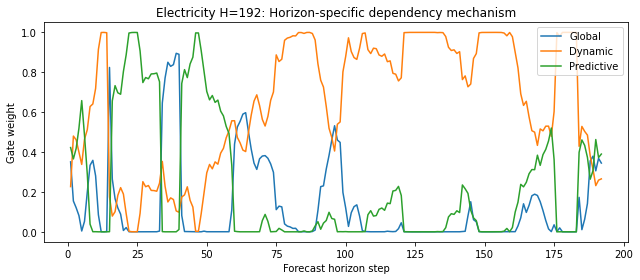

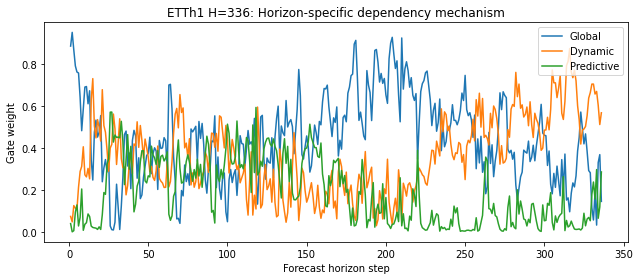

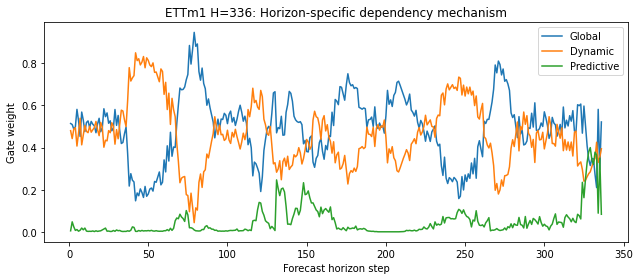

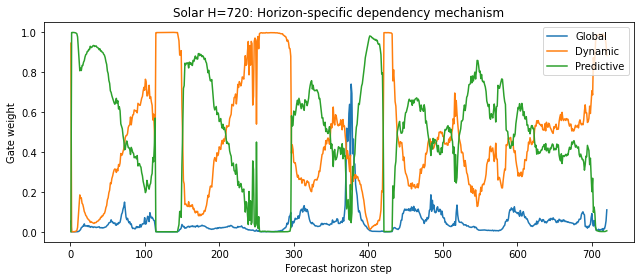

In [17]:
for dataset_name, H in CONDITIONS:
    p = (
        variant_dir(
            dataset_name,
            H,
            "HorizonGatedMixture",
        )
        / "per_horizon.csv"
    )

    if not p.exists():
        continue

    df = pd.read_csv(p)

    plt.figure(
        figsize=(9, 4)
    )

    plt.plot(
        df["horizon_step"],
        df["gate_global"],
        label="Global",
    )

    plt.plot(
        df["horizon_step"],
        df["gate_dynamic"],
        label="Dynamic",
    )

    plt.plot(
        df["horizon_step"],
        df["gate_predictive"],
        label="Predictive",
    )

    plt.xlabel(
        "Forecast horizon step"
    )

    plt.ylabel(
        "Gate weight"
    )

    plt.title(
        f"{dataset_name} H={H}: Horizon-specific dependency mechanism"
    )

    plt.legend()

    plt.tight_layout()
    plt.show()


# 16. Decision rule

This section implements the matched horizon-specific topology-transfer mechanism. Predictive-utility source sets are computed from training data and then imposed on the neural forecaster as specified in the paper.
